In [1]:
import os
import numpy as np
import tensorflow as tf
from keras.layers import Dense, Conv1D, MaxPool1D, Flatten
from keras import Sequential
from keras import optimizers
import kerastuner 
from kerastuner import HyperModel
from kerastuner.tuners import Hyperband
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from keras.callbacks import Callback,EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from IPython.display import clear_output
pd.set_option('display.max_rows', None)

In [2]:
class PlotLosses(Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.accuracies = []
        self.val_losses = []
        self.val_accuracies = []
        
        self.fig = plt.figure()
        
        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.accuracies.append(logs.get('acc'))
        self.val_losses.append(logs.get('val_loss'))
        self.val_accuracies.append(logs.get('val_acc'))
        self.i += 1
        
        clear_output(wait=True)
        plt.plot(self.x, self.losses, label="loss")
        plt.plot(self.x, self.accuracies, label="accuracy")
        plt.plot(self.x, self.val_losses, label="val_loss")
        plt.plot(self.x, self.val_accuracies, label="val_accuracy")
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)),plt.grid()
        plt.show();
        
plot_losses = PlotLosses()

In [3]:
#DEFINING DETECTOR AND POISSON 
detector="O3"
poisson=4
directory="/m100_work/IscrC_DeepSBKG/fmarangi/"

In [4]:
#TRAINING+VALIDATION SET(85 % OF DATA)

for i in np.arange(0,85,85):
    print('BBH'+str(poisson)+'s_serie'+str(i)+'.csv')
    inputdata=pd.read_csv(directory+str(poisson)+"sw"+str(detector)+"/BBH"+str(poisson)+"s_serie"+str(i)+".csv")
    for j in range(i+1,i+85):
        if j==25:
            continue
        print('BBH'+str(poisson)+'s_serie'+str(j)+'.csv')
        inputdata_append=pd.read_csv(directory+str(poisson)+"sw"+str(detector)+"/BBH"+str(poisson)+"s_serie"+str(j)+".csv")
        del inputdata_append['Unnamed: 0']
        inputdata=pd.concat([inputdata,inputdata_append])
        
inputdata=shuffle(inputdata)
columnsET=[str(l) for l in range(8192)]
inputs_train=inputdata[columnsET].values
inputs_train=preprocessing.minmax_scale(inputs_train.T).T

targets_train=inputdata['Label'].values

inputs_train = inputs_train.reshape((inputs_train.shape[0], inputs_train.shape[1], 1))
onehot_encoder = OneHotEncoder(sparse=False)
targets_train = targets_train.reshape(targets_train.shape[0], 1)
targets_train = onehot_encoder.fit_transform(targets_train)
x_train, x_val, y_train, y_val = train_test_split(inputs_train, targets_train, test_size=0.3)
n_classes = len(np.unique(targets_train))

BBH4s_serie0.csv
BBH4s_serie1.csv
BBH4s_serie2.csv
BBH4s_serie3.csv
BBH4s_serie4.csv
BBH4s_serie5.csv
BBH4s_serie6.csv
BBH4s_serie7.csv
BBH4s_serie8.csv
BBH4s_serie9.csv
BBH4s_serie10.csv
BBH4s_serie11.csv
BBH4s_serie12.csv
BBH4s_serie13.csv
BBH4s_serie14.csv
BBH4s_serie15.csv
BBH4s_serie16.csv
BBH4s_serie17.csv
BBH4s_serie18.csv
BBH4s_serie19.csv
BBH4s_serie20.csv
BBH4s_serie21.csv
BBH4s_serie22.csv
BBH4s_serie23.csv
BBH4s_serie24.csv
BBH4s_serie26.csv
BBH4s_serie27.csv
BBH4s_serie28.csv
BBH4s_serie29.csv
BBH4s_serie30.csv
BBH4s_serie31.csv
BBH4s_serie32.csv
BBH4s_serie33.csv
BBH4s_serie34.csv
BBH4s_serie35.csv
BBH4s_serie36.csv
BBH4s_serie37.csv
BBH4s_serie38.csv
BBH4s_serie39.csv
BBH4s_serie40.csv
BBH4s_serie41.csv
BBH4s_serie42.csv
BBH4s_serie43.csv
BBH4s_serie44.csv
BBH4s_serie45.csv
BBH4s_serie46.csv
BBH4s_serie47.csv
BBH4s_serie48.csv
BBH4s_serie49.csv
BBH4s_serie50.csv
BBH4s_serie51.csv
BBH4s_serie52.csv
BBH4s_serie53.csv
BBH4s_serie54.csv
BBH4s_serie55.csv
BBH4s_serie56.csv
BB

In [5]:
#TESTING SET (15 % OF DATA)

for i in np.arange(85,100,15):
    print('BBH'+str(poisson)+'s_serie'+str(i)+'.csv')
    testdata=pd.read_csv(directory+str(poisson)+"sw"+str(detector)+"/BBH"+str(poisson)+"s_serie"+str(i)+".csv")
    for j in range(i+1,i+15):
        print('BBH'+str(poisson)+'s_serie'+str(j)+'.csv')
        testdata_append=pd.read_csv(directory+str(poisson)+"sw"+str(detector)+"/BBH"+str(poisson)+"s_serie"+str(j)+".csv")
        del testdata_append['Unnamed: 0']
        testdata=pd.concat([testdata,testdata_append])
    
testdata=shuffle(testdata)
columnsET=[str(l) for l in range(8192)]
inputs_test=testdata[columnsET].values
inputs_test=preprocessing.minmax_scale(inputs_test.T).T
targets_test=testdata['Label'].values
inputs_test = inputs_test.reshape((inputs_test.shape[0], inputs_test.shape[1], 1))
onehot_encoder = OneHotEncoder(sparse=False)
targets_test = targets_test.reshape(targets_test.shape[0], 1)
targets_test = onehot_encoder.fit_transform(targets_test)


BBH4s_serie85.csv
BBH4s_serie86.csv
BBH4s_serie87.csv
BBH4s_serie88.csv
BBH4s_serie89.csv
BBH4s_serie90.csv
BBH4s_serie91.csv
BBH4s_serie92.csv
BBH4s_serie93.csv
BBH4s_serie94.csv
BBH4s_serie95.csv
BBH4s_serie96.csv
BBH4s_serie97.csv
BBH4s_serie98.csv
BBH4s_serie99.csv


In [11]:
#CLASS TUNING AND FUNCTION

class CNNHyperModel(HyperModel):
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes
    def build(self, hp): 
        model = Sequential()
        
        filters1=hp.Choice(
            'num_filters1',
            values=[70,100,130,160,190,220,250,280,310],
            default=130,
            
        )
        
        filters2=hp.Choice(
            'num_filters2',
            values=[70,100,130,160,190,220,250,280,310],
            
            default=130,
        )
        filters3=hp.Choice(
            'num_filters3',
            values=[70,100,130,160,190,220,250,280,310],
            
            default=130,
        )
        filters4=hp.Choice(
            'num_filters4',
            values=[70,100,130,160,190,220,250,280,310],
            
            default=130,
        )
        filters5=hp.Choice(
            'num_filters5',
            values=[70,100,130,160,190,220,250,280,310],
            
            default=130,
        )
        filters6=hp.Choice(
            'num_filters6',
            values=[70,100,130,160,190,220,250,280,310],
            
            default=130,
        )
        filters7=hp.Choice(
            'num_filters7',
            values=[70,100,130,160,190,220,250,280,310],
            
            default=130,
        )
        filters8=hp.Choice(
            'num_filters8',
            values=[70,100,130,160,190,220,250,280,310],
            
            default=130,
        )
        kernel_size1=hp.Choice(
            'kernel_size1',
            values=[8,16,24,32,40,48],
        
            default=40,
        )
        
        
        kernel_size2=hp.Choice(
            'kernel_size2',
            values=[8,16,24,32,40,48],
        
            default=40,
        )
       
        kernel_size3=hp.Choice(
            'kernel_size3',
            values=[8,16,24,32,40,48],
        
            default=40,
        )
        
        
        kernel_size4=hp.Choice(
            'kernel_size4',
            values=[8,16,24,32,40,48],
        
            default=40,
        )
        
        kernel_size5=hp.Choice(
            'kernel_size5',
            values=[8,16,24,32,40,48],
        
            default=40,
        )
        
        
        kernel_size6=hp.Choice(
            'kernel_size6',
            values=[8,16,24,32,40,48],
        
            default=40,
        )
        kernel_size7=hp.Choice(
            'kernel_size7',
            values=[8,16,24,32,40,48],
        
            default=40,
        )
        kernel_size8=hp.Choice(
            'kernel_size8',
            values=[8,16,24,32,40,48],
        
            default=40,
        )
        pool_size1=hp.Choice(
            'poolsize1',
            values=[2,3,4],
            default=2,
        )
        pool_size2=hp.Choice(
            'poolsize2',
            values=[2,3,4],
            default=2,
        )
        pool_size3=hp.Choice(
            'poolsize3',
            values=[2,3,4],
            default=2,
        )
        pool_size4=hp.Choice(
            'poolsize4',
            values=[2,3,4],
            default=2,
        )
        pool_size5=hp.Choice(
            'poolsize5',
            values=[2,3,4],
            default=2,
        )
        pool_size6=hp.Choice(
            'poolsize6',
            values=[2,3,4],
            default=2,
        )
        pool_size7=hp.Choice(
            'poolsize7',
            values=[2,3,4],
            default=2,
        )
        pool_size8=hp.Choice(
            'poolsize8',
            values=[2,3,4],
            default=2,
        )
        
        n_convs=hp.Choice('N_convs',values=[6,7,8],default=6)
        maxpool_on_off1=hp.Choice('Maxpool_on_off1',values=[0,1], default=1)
        maxpool_on_off2=hp.Choice('Maxpool_on_off2',values=[0,1], default=1)
        maxpool_on_off3=hp.Choice('Maxpool_on_off3',values=[0,1], default=1)
        maxpool_on_off4=hp.Choice('Maxpool_on_off4',values=[0,1], default=1)
        maxpool_on_off5=hp.Choice('Maxpool_on_off5',values=[0,1], default=1)
        maxpool_on_off6=hp.Choice('Maxpool_on_off6',values=[0,1], default=1)
        maxpool_on_off7=hp.Choice('Maxpool_on_off7',values=[0,1], default=1)
        maxpool_on_off8=hp.Choice('Maxpool_on_off8',values=[0,1], default=1)
        
        n_dense=hp.Choice('N_dense',values=[0,1,2],default=2)
        units1=hp.Choice('Dense1',values=[25,50,100],default=100)
        units2=hp.Choice('Dense2',values=[25,50,100],default=50)
        size=input_shape
        pad=hp.Choice('Padding',values=[0,1],default=1)
       
            
        if pad==0:

            if  (size-kernel_size1+1)>0:
                model.add(Conv1D(filters1, kernel_size1, activation="relu", input_shape=self.input_shape))
                size=size-kernel_size1+1
            if maxpool_on_off1==1 and (size>pool_size1):
                model.add(MaxPool1D(pool_size1))
                size=int(size/pool_size1)
            if (size-kernel_size2+1)>0:
                model.add(Conv1D(filters2, kernel_size2, activation="relu"))
                size=size-kernel_size2+1
            if maxpool_on_off2==1 and (size>pool_size2):
                model.add(MaxPool1D(pool_size2))
                size=int(size/pool_size2)
            if (size-kernel_size3+1)>0: 
                model.add(Conv1D(filters3, kernel_size3, activation="relu"))
                size=size-kernel_size3+1
            if maxpool_on_off3==1 and (size>pool_size2):
                model.add(MaxPool1D(pool_size3))
                size=int(size/pool_size3)
            if (size-kernel_size4+1)>0:
                model.add(Conv1D(filters4, kernel_size4, activation="relu"))
                size=size-kernel_size4+1 
            if maxpool_on_off4==1 and (size>pool_size4):
                model.add(MaxPool1D(pool_size4))
                size=int(size/pool_size4)
            if (size-kernel_size5+1)>0:
                model.add(Conv1D(filters5, kernel_size5, activation="relu"))
                size=size-kernel_size5+1
            if maxpool_on_off5==1 and (size>pool_size5):
                model.add(MaxPool1D(pool_size5))
                size=int(size/pool_size5)
            if (n_convs==6 or n_convs==7 or n_convs==8) and ((size-kernel_size6+1)>0):
                model.add(Conv1D(filters6, kernel_size6, activation="relu"))
                size=size-kernel_size6+1
            if maxpool_on_off6==1 and (size>pool_size6):
                model.add(MaxPool1D(pool_size6))
                size=int(size/pool_size6)
            if  (n_convs==7 or n_convs==8) and ((size-kernel_size7+1)>0):
                model.add(Conv1D(filters7, kernel_size7, activation="relu"))
                size=size-kernel_size7+1
            if (maxpool_on_off7==1) and (size>pool_size7) :
                model.add(MaxPool1D(pool_size7))
                size=int(size/pool_size7)
            if  (n_convs==8) and ((size-kernel_size8+1)>0):
                model.add(Conv1D(filters8, kernel_size8, activation="relu"))
                size=size-kernel_size8+1
            if (maxpool_on_off8==1) and (size>pool_size8) :
                model.add(MaxPool1D(pool_size8))
                size=int(size/pool_size8)
            
                
        if pad==1:
            model.add(Conv1D(filters1, kernel_size1, activation="relu", padding="same" ,input_shape=self.input_shape))
            if maxpool_on_off1==1 and (size>pool_size1):
                model.add(MaxPool1D(pool_size1))
                size=int(size/pool_size1)
            model.add(Conv1D(filters2, kernel_size2, padding="same", activation="relu"))
            if maxpool_on_off2==1 and (size>pool_size2):
                model.add(MaxPool1D(pool_size2))
                size=int(size/pool_size2)
            model.add(Conv1D(filters3, kernel_size3, padding="same", activation="relu"))
            if maxpool_on_off3==1 and (size>pool_size2):
                model.add(MaxPool1D(pool_size3))
                size=int(size/pool_size3)
            model.add(Conv1D(filters4, kernel_size4, padding="same",activation="relu"))
            if maxpool_on_off4==1 and (size>pool_size4):
                model.add(MaxPool1D(pool_size4))
                size=int(size/pool_size4)
            model.add(Conv1D(filters5, kernel_size5, padding="same",activation="relu"))
            if maxpool_on_off5==1 and (size>pool_size5):
                model.add(MaxPool1D(pool_size5))
                size=int(size/pool_size5)
            if n_convs==6 or n_convs==7 or n_convs==8:
                model.add(Conv1D(filters6, kernel_size6, padding="same", activation="relu"))
            if maxpool_on_off6==1 and (size>pool_size6):
                model.add(MaxPool1D(pool_size6))
                size=int(size/pool_size6)
            if  n_convs==7 or n_convs==8:
                model.add(Conv1D(filters7, kernel_size7, padding="same",activation="relu"))
            if (maxpool_on_off7==1) and (size>pool_size7) :
                model.add(MaxPool1D(pool_size7))
                size=int(size/pool_size7)
            if  n_convs==8:
                model.add(Conv1D(filters8, kernel_size8, padding="same",activation="relu"))
            if (maxpool_on_off8==1) and (size>pool_size8) :
                model.add(MaxPool1D(pool_size8))
                size=int(size/pool_size8)
            
            
        model.add(Flatten())
        if n_dense==0:
            model.add(Dense(self.num_classes, activation="softmax"))
        if n_dense==1:
            model.add(Dense(units1, activation="relu"))
            model.add(Dense(self.num_classes, activation="softmax"))
        if n_dense==2:
            model.add(Dense(units1, activation="relu"))
            model.add(Dense(units2, activation="relu"))
            model.add(Dense(self.num_classes, activation="softmax"))
    

        
        
        learning_rate=0.00001

        opt = optimizers.Adam(lr=learning_rate)
        
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=["acc"])
        
        return model


    


In [12]:
#CALLING TUNING 
INPUT_SHAPE=(8192,1)
NUM_CLASSES=2
SEED=1
HYPERBAND_MAX_EPOCHS =70
EXECUTION_PER_TRIAL = 1
N_EPOCH_SEARCH=70
BATCH_SIZE=32


hypermodel = CNNHyperModel(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)

tuner = Hyperband(
    hypermodel,
    max_epochs=HYPERBAND_MAX_EPOCHS,
    objective='val_acc',
    seed=SEED,
    executions_per_trial=EXECUTION_PER_TRIAL,
    directory='hyperband',
    project_name='SGWB1_ET_BBH4s_withened_data_3convs'
)


tuner.search_space_summary()


In [13]:
#TUNING

tuner.search(x_train, y_train, epochs=N_EPOCH_SEARCH, batch_size=32, validation_data=(x_val,y_val), callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_acc',patience=7)])
#Show a summary of the search
tuner.results_summary()

# Retrieve the best model.

best_model = tuner.get_best_models(num_models=1)[0]

loss, accuracy = best_model.evaluate(inputs_test, targets_test)
print(loss,accuracy)

    
    
    


Epoch 1/3
 646/1884 [=========>....................] - ETA: 26s - loss: 0.6921 - acc: 0.53 - ETA: 29s - loss: 0.6928 - acc: 0.51 - ETA: 31s - loss: 0.6930 - acc: 0.51 - ETA: 31s - loss: 0.6935 - acc: 0.50 - ETA: 32s - loss: 0.6929 - acc: 0.51 - ETA: 32s - loss: 0.6921 - acc: 0.53 - ETA: 32s - loss: 0.6921 - acc: 0.53 - ETA: 32s - loss: 0.6929 - acc: 0.52 - ETA: 32s - loss: 0.6929 - acc: 0.52 - ETA: 32s - loss: 0.6931 - acc: 0.51 - ETA: 32s - loss: 0.6929 - acc: 0.52 - ETA: 32s - loss: 0.6933 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.51 - ETA: 32s - loss: 0.6931 - acc: 0.52 - ETA: 32s - loss: 0.6931 - acc: 0.52 - ETA: 32s - loss: 0.6935 - acc: 0.51 - ETA: 32s - loss: 0.6935 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.51 - ETA: 32s - loss: 0.6934 - acc: 0.

Epoch 1/3
 431/1884 [=====>........................] - ETA: 42s - loss: 0.6900 - acc: 0.56 - ETA: 49s - loss: 0.6911 - acc: 0.55 - ETA: 52s - loss: 0.6906 - acc: 0.54 - ETA: 54s - loss: 0.6940 - acc: 0.53 - ETA: 55s - loss: 0.6930 - acc: 0.53 - ETA: 55s - loss: 0.6914 - acc: 0.54 - ETA: 56s - loss: 0.6923 - acc: 0.53 - ETA: 56s - loss: 0.6931 - acc: 0.52 - ETA: 56s - loss: 0.6932 - acc: 0.52 - ETA: 56s - loss: 0.6932 - acc: 0.52 - ETA: 57s - loss: 0.6931 - acc: 0.52 - ETA: 57s - loss: 0.6933 - acc: 0.51 - ETA: 57s - loss: 0.6932 - acc: 0.51 - ETA: 57s - loss: 0.6934 - acc: 0.50 - ETA: 57s - loss: 0.6931 - acc: 0.51 - ETA: 57s - loss: 0.6933 - acc: 0.51 - ETA: 57s - loss: 0.6930 - acc: 0.51 - ETA: 57s - loss: 0.6929 - acc: 0.51 - ETA: 57s - loss: 0.6928 - acc: 0.51 - ETA: 57s - loss: 0.6934 - acc: 0.51 - ETA: 57s - loss: 0.6935 - acc: 0.51 - ETA: 57s - loss: 0.6936 - acc: 0.50 - ETA: 57s - loss: 0.6937 - acc: 0.50 - ETA: 57s - loss: 0.6937 - acc: 0.50 - ETA: 57s - loss: 0.6938 - acc: 0.

Epoch 1/3
 431/1884 [=====>........................] - ETA: 42s - loss: 0.6945 - acc: 0.47 - ETA: 50s - loss: 0.6941 - acc: 0.46 - ETA: 53s - loss: 0.6936 - acc: 0.51 - ETA: 54s - loss: 0.6934 - acc: 0.52 - ETA: 55s - loss: 0.6934 - acc: 0.51 - ETA: 56s - loss: 0.6938 - acc: 0.50 - ETA: 56s - loss: 0.6936 - acc: 0.50 - ETA: 57s - loss: 0.6939 - acc: 0.49 - ETA: 57s - loss: 0.6941 - acc: 0.49 - ETA: 57s - loss: 0.6940 - acc: 0.48 - ETA: 57s - loss: 0.6940 - acc: 0.48 - ETA: 57s - loss: 0.6939 - acc: 0.48 - ETA: 57s - loss: 0.6938 - acc: 0.49 - ETA: 57s - loss: 0.6938 - acc: 0.49 - ETA: 58s - loss: 0.6939 - acc: 0.48 - ETA: 58s - loss: 0.6937 - acc: 0.49 - ETA: 58s - loss: 0.6936 - acc: 0.49 - ETA: 58s - loss: 0.6935 - acc: 0.50 - ETA: 58s - loss: 0.6935 - acc: 0.50 - ETA: 58s - loss: 0.6932 - acc: 0.50 - ETA: 58s - loss: 0.6934 - acc: 0.50 - ETA: 58s - loss: 0.6935 - acc: 0.50 - ETA: 58s - loss: 0.6936 - acc: 0.50 - ETA: 58s - loss: 0.6937 - acc: 0.49 - ETA: 58s - loss: 0.6937 - acc: 0.


KeyboardInterrupt



In [9]:
#BEST MODEL FROM TUNING
best_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 4096, 280)         7000      
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 4096, 310)         3472310   
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 1365, 310)         0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 1365, 130)         967330    
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 1365, 160)         832160    
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 682, 160)          0         
_________________________________________________________________
conv1d_4 (Conv1D)            (None, 682, 190)          2

In [15]:
# 3 MODELS CHOSEN AND 3 TRAINING TRIALS MADE FOR EACH MODEL
trial=1
model_n=2


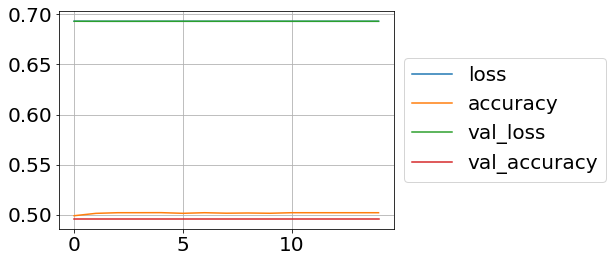


Epoch 00015: val_acc did not improve from 0.49566
1882/1882 [==============================] - 169s 90ms/step - loss: 0.6931 - acc: 0.5019 - val_loss: 0.6932 - val_acc: 0.4957
Epoch 16/300
 204/1882 [==>...........................] - ETA: 0s - loss: 0.6930 - acc: 0.531 - ETA: 1:15 - loss: 0.6932 - acc: 0.484 - ETA: 1:44 - loss: 0.6933 - acc: 0.479 - ETA: 1:56 - loss: 0.6933 - acc: 0.476 - ETA: 2:03 - loss: 0.6933 - acc: 0.481 - ETA: 2:08 - loss: 0.6933 - acc: 0.474 - ETA: 2:11 - loss: 0.6933 - acc: 0.473 - ETA: 2:16 - loss: 0.6934 - acc: 0.460 - ETA: 2:18 - loss: 0.6934 - acc: 0.458 - ETA: 2:19 - loss: 0.6933 - acc: 0.468 - ETA: 2:20 - loss: 0.6934 - acc: 0.454 - ETA: 2:21 - loss: 0.6934 - acc: 0.460 - ETA: 2:22 - loss: 0.6933 - acc: 0.468 - ETA: 2:22 - loss: 0.6933 - acc: 0.468 - ETA: 2:26 - loss: 0.6933 - acc: 0.477 - ETA: 2:26 - loss: 0.6932 - acc: 0.484 - ETA: 2:26 - loss: 0.6932 - acc: 0.483 - ETA: 2:26 - loss: 0.6933 - acc: 0.475 - ETA: 2:27 - loss: 0.6933 - acc: 0.472 - ETA: 2:

In [ ]:
#FITTING MODEL
model = Sequential()

if model_n==1:
    model.add(Conv1D(filters=70, kernel_size=8, activation="relu",input_shape=(8192,1)))
    model.add(Conv1D(filters=130, kernel_size=8, activation="relu"))
    model.add(Conv1D(filters=250, kernel_size=24,activation="relu"))
    model.add(MaxPool1D(3))
    model.add(Conv1D(filters=220, kernel_size=16,activation="relu"))
    model.add(Conv1D(filters=190, kernel_size=24, activation="relu"))
    model.add(MaxPool1D(4))
    model.add(Conv1D(filters=130, kernel_size=46, activation="relu"))

    model.add(Flatten())
    model.add(Dense(100, activation="relu"))
    model.add(Dense(2, activation="softmax"))


if model_n==2:
    model.add(Conv1D(filters=220, kernel_size=24, padding="same", activation="relu", input_shape=(8192,1)))
    model.add(MaxPool1D(4))
    model.add(Conv1D(filters=280, kernel_size=24,padding="same", activation="relu"))
    model.add(Conv1D(filters=100, kernel_size=8,padding="same",activation="relu"))
    model.add(MaxPool1D(2))
    model.add(Conv1D(filters=190, kernel_size=46, padding="same",activation="relu"))
    model.add(Conv1D(filters=130, kernel_size=24,padding="same", activation="relu"))
    model.add(Conv1D(filters=250, kernel_size=8, padding="same",activation="relu"))
    model.add(Conv1D(filters=130, kernel_size=24, padding="same",activation="relu"))

    model.add(Flatten())

    model.add(Dense(2, activation="softmax"))

if model_n==3:
    model.add(Conv1D(filters=280, kernel_size=24, padding="same",activation="relu",input_shape=(8192,1)))
    model.add(Conv1D(filters=310, kernel_size=40,padding="same", activation="relu"))
    model.add(MaxPool1D(3))
    model.add(Conv1D(filters=130, kernel_size=24,padding="same", activation="relu"))
    model.add(Conv1D(filters=160, kernel_size=40,padding="same",activation="relu"))
    model.add(MaxPool1D(2))
    model.add(Conv1D(filters=190, kernel_size=8, padding="same",activation="relu"))
    model.add(MaxPool1D(3))
    model.add(Conv1D(filters=280, kernel_size=48,padding="same", activation="relu"))
    model.add(Conv1D(filters=250, kernel_size=32, padding="same",activation="relu"))
    model.add(MaxPool1D(3))
    model.add(Conv1D(filters=220, kernel_size=24, padding="same",activation="relu"))

    model.add(Flatten())

    model.add(Dense(2, activation="softmax"))



opt = optimizers.Adam(lr=0.00001)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=["acc"])

model_checkpoint = ModelCheckpoint('best_weights_poisson'+str(poisson)+detector+'_model'+str(model_n)+'_trail'+str(trial)+'.h5', monitor='val_acc',verbose=1, save_best_only=True)
es=EarlyStopping(monitor='val_acc',min_delta=0.00005,mode='max',verbose=1,patience=50,restore_best_weights=True)
#reduce_lr = ReduceLROnPlateau(monitor='val_acc', factor=0.1,patience=1, min_lr=0.0000001)

model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val), callbacks=[plot_losses,es,model_checkpoint],shuffle=True)


(1.5, -0.5)

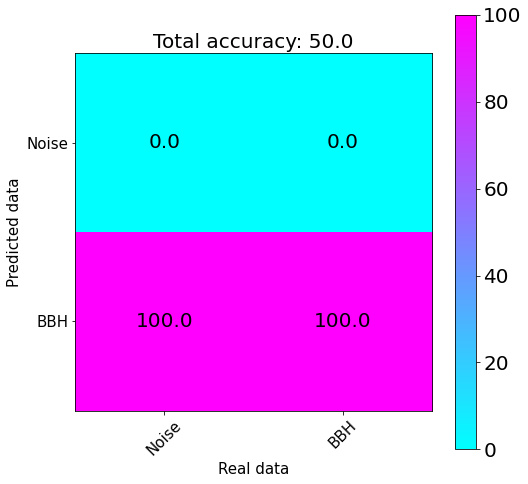

In [11]:
#TESTING-CONFUSION MATRIX

model.load_weights('best_weights_poisson'+str(poisson)+detector+'_model'+str(model_n)+'_trail'+str(trial)+'.h5')
y_predicted = model.predict(inputs_test)
cms = confusion_matrix(targets_test.argmax(1), y_predicted.argmax(1)) 
test_score = np.trace(cms) / np.sum(cms) 
new_cms = np.zeros((n_classes,n_classes))
for x in range(n_classes):
    for y in range(n_classes):
        new_cms[x,y] = round(cms[x,y] / np.sum(cms[x])*100,1)
plt.rc("font", size=20)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)
im = ax.imshow(np.transpose(new_cms), interpolation="nearest", cmap="cool")
for x in range(0, n_classes):
    for y in range(0, n_classes):
        ax.text(x, y, new_cms[x,y], color="black", ha="center", va="center")
plt.title("Total accuracy: " + str(np.around(test_score*100, 1)), fontsize=20)

plt.colorbar(im)

classes_values = []
classes_labels = ["Noise", "BBH"]
for n in range(n_classes):
    classes_values.append(n)

plt.xticks(classes_values, classes_labels, rotation=45, fontsize=15)
plt.yticks(classes_values, classes_labels, fontsize=15)
plt.xlabel("Real data", fontsize=15)
plt.ylabel("Predicted data", fontsize=15), plt.ylim([-0.5,n_classes-0.5])
axis = plt.gca()
ax.set_ylim(ax.get_ylim()[::-1])

In [12]:
print("True positives"+str(cms[1,1]))
print("True negatives"+str(cms[0,0]))
print("False negatives"+str(cms[1,0]))
print("False positives"+str(cms[0,1]))


True positives7551
True negatives0
False negatives0
False positives7551
